- Barot Devanshu <br>
- Enginnering Physics <br>
- 23123011<br>
- 2nd Year<br>
- DAI-101 Assignment1

# 1. Data Selection & Preprocessing

## Loading the Dataset
The dataset is the data from Kaggle named as Diabetes <br>
It can be accessed from the link below👇<br>
<a>https://www.kaggle.com/datasets/imtkaggleteam/diabetes/data</a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import log_loss
from mlxtend.evaluate import bias_variance_decomp
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('diabetes.csv')
data

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.310000,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.440000,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.640000,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.630000,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.720000,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,41506,296.0,369,46.0,6.4,16.110001,Louisa,53,male,69.0,173.0,medium,138.0,94.0,130.0,94.0,35.0,39.0,210.0
399,41507,284.0,89,54.0,5.3,4.390000,Louisa,51,female,63.0,154.0,medium,140.0,100.0,146.0,102.0,32.0,43.0,180.0
400,41510,194.0,269,38.0,5.1,13.630000,Louisa,29,female,69.0,167.0,small,120.0,70.0,NaN,NaN,33.0,40.0,20.0
401,41752,199.0,76,52.0,3.8,4.490000,Louisa,41,female,63.0,197.0,medium,120.0,78.0,NaN,NaN,41.0,48.0,255.0


## Preprocessing

In this dataset we cant fill just another value as we are predicting the data for diabetes.<br>
So we will just drop the nan values. <br>
Also we will drop unnecessay predictors in out data<br><br>
Lastly ,<br>We are given in dataset that it **value of glyhb is > 6.5** then there is diabetes,<br>and **if glyhb < 6.5 , its not**

In [ ]:
data.columns

Index(['id', 'chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'location', 'age',
       'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s',
       'bp.2d', 'waist', 'hip', 'time.ppn'],
      dtype='object')

In [ ]:
#dropping unneccasry columns
data=data.drop(['id','location','frame','bp.2s','bp.2d','time.ppn','ratio'],axis=1)

In [ ]:
data

,chol,stab.glu,hdl,glyhb,age,gender,height,weight,bp.1s,bp.1d,waist,hip
0,203.0,82,56.0,4.310000,46,female,62.0,121.0,118.0,59.0,29.0,38.0
1,165.0,97,24.0,4.440000,29,female,64.0,218.0,112.0,68.0,46.0,48.0
2,228.0,92,37.0,4.640000,58,female,61.0,256.0,190.0,92.0,49.0,57.0
3,78.0,93,12.0,4.630000,67,male,67.0,119.0,110.0,50.0,33.0,38.0
4,249.0,90,28.0,7.720000,64,male,68.0,183.0,138.0,80.0,44.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...
398,296.0,369,46.0,16.110001,53,male,69.0,173.0,138.0,94.0,35.0,39.0
399,284.0,89,54.0,4.390000,51,female,63.0,154.0,140.0,100.0,32.0,43.0
400,194.0,269,38.0,13.630000,29,female,69.0,167.0,120.0,70.0,33.0,40.0
401,199.0,76,52.0,4.490000,41,female,63.0,197.0,120.0,78.0,41.0,48.0


In [ ]:
new_data=data.dropna()

In [ ]:
ohe=pd.get_dummies(data=new_data['gender'])
ohe=ohe.astype(int)['male']
new_data=pd.concat([new_data,ohe],axis=1)
new_data=new_data.drop(['gender'],axis=1)

In [ ]:
# the people with hameoglobin a1c > 6.5 has dibates --1 rest < 6.5 do not have --0
new_data['diabetes_or_not']=new_data['glyhb'].apply(lambda x: 1 if x>6.5 else 0)

In [ ]:
new_data=new_data.drop(['glyhb'],axis=1)

In [ ]:
new_data

,chol,stab.glu,hdl,age,height,weight,bp.1s,bp.1d,waist,hip,male,diabetes_or_not
0,203.0,82,56.0,46,62.0,121.0,118.0,59.0,29.0,38.0,0,0
1,165.0,97,24.0,29,64.0,218.0,112.0,68.0,46.0,48.0,0,0
2,228.0,92,37.0,58,61.0,256.0,190.0,92.0,49.0,57.0,0,0
3,78.0,93,12.0,67,67.0,119.0,110.0,50.0,33.0,38.0,1,0
4,249.0,90,28.0,64,68.0,183.0,138.0,80.0,44.0,41.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
397,301.0,90,118.0,89,61.0,115.0,218.0,90.0,31.0,41.0,0,0
398,296.0,369,46.0,53,69.0,173.0,138.0,94.0,35.0,39.0,1,1
399,284.0,89,54.0,51,63.0,154.0,140.0,100.0,32.0,43.0,0,0
400,194.0,269,38.0,29,69.0,167.0,120.0,70.0,33.0,40.0,0,1


In [ ]:
X=new_data.iloc[:,:-1]
y=new_data.iloc[:,-1]

In [ ]:
scaler=MinMaxScaler()

In [ ]:
X

,chol,stab.glu,hdl,age,height,weight,bp.1s,bp.1d,waist,hip,male
0,203.0,82,56.0,46,62.0,121.0,118.0,59.0,29.0,38.0,0
1,165.0,97,24.0,29,64.0,218.0,112.0,68.0,46.0,48.0,0
2,228.0,92,37.0,58,61.0,256.0,190.0,92.0,49.0,57.0,0
3,78.0,93,12.0,67,67.0,119.0,110.0,50.0,33.0,38.0,1
4,249.0,90,28.0,64,68.0,183.0,138.0,80.0,44.0,41.0,1
...,...,...,...,...,...,...,...,...,...,...,...
397,301.0,90,118.0,89,61.0,115.0,218.0,90.0,31.0,41.0,0
398,296.0,369,46.0,53,69.0,173.0,138.0,94.0,35.0,39.0,1
399,284.0,89,54.0,51,63.0,154.0,140.0,100.0,32.0,43.0,0
400,194.0,269,38.0,29,69.0,167.0,120.0,70.0,33.0,40.0,0


In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

- Lets also apply minmax scaler to bring features into one scale
- as our features are on diffrent scale

In [ ]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[0.48471616, 0.13946588, 0.56603774, ..., 0.36666667, 0.35294118,
        0.        ],
       [0.33624454, 0.36498516, 0.14150943, ..., 0.46666667, 0.29411765,
        1.        ],
       [0.29694323, 0.14540059, 0.33962264, ..., 0.53333333, 0.32352941,
        1.        ],
       ...,
       [0.69432314, 0.11869436, 0.29245283, ..., 0.63333333, 0.70588235,
        0.        ],
       [0.33187773, 0.13946588, 0.20754717, ..., 0.6       , 0.67647059,
        0.        ],
       [0.29694323, 0.07715134, 0.58490566, ..., 0.16666667, 0.23529412,
        1.        ]])

In [ ]:
scaler=MinMaxScaler()

In [ ]:
X_test

array([[0.37554585, 0.37091988, 0.21698113, ..., 0.33333333, 0.52941176,
        1.        ],
       [0.08733624, 0.13946588, 0.24528302, ..., 0.16666667, 0.26470588,
        0.        ],
       [0.76419214, 0.19881306, 0.37735849, ..., 0.26666667, 0.26470588,
        1.        ],
       ...,
       [0.26637555, 0.10979228, 0.35849057, ..., 0.36666667, 0.5       ,
        0.        ],
       [0.50655022, 0.0504451 , 0.58490566, ..., 0.63333333, 0.47058824,
        1.        ],
       [0.30567686, 0.11869436, 0.3490566 , ..., 0.26666667, 0.32352941,
        0.        ]])

# 2. Exploratory Data Analysis

In [ ]:
## stats summary for the dataset
print(new_data.describe())

             chol    stab.glu         hdl         age      height      weight  \
count  377.000000  377.000000  377.000000  377.000000  377.000000  377.000000   
mean   207.740053  107.519894   50.405836   46.920424   66.010610  177.997347   
std     44.641793   53.961080   17.414755   16.637532    3.910555   40.499836   
min     78.000000   48.000000   12.000000   19.000000   52.000000   99.000000   
25%    179.000000   81.000000   38.000000   34.000000   63.000000  151.000000   
50%    204.000000   90.000000   46.000000   45.000000   66.000000  174.000000   
75%    230.000000  108.000000   59.000000   60.000000   69.000000  200.000000   
max    443.000000  385.000000  120.000000   92.000000   76.000000  325.000000   

            bp.1s       bp.1d       waist         hip        male  \
count  377.000000  377.000000  377.000000  377.000000  377.000000   
mean   137.395225   83.429708   37.957560   43.082228    0.416446   
std     23.131798   13.527984    5.761972    5.630098    0.4936

In [ ]:
eda_data=new_data.drop(columns=['diabetes_or_not'])

In [ ]:
eda_data

,chol,stab.glu,hdl,age,height,weight,bp.1s,bp.1d,waist,hip,male
0,203.0,82,56.0,46,62.0,121.0,118.0,59.0,29.0,38.0,0
1,165.0,97,24.0,29,64.0,218.0,112.0,68.0,46.0,48.0,0
2,228.0,92,37.0,58,61.0,256.0,190.0,92.0,49.0,57.0,0
3,78.0,93,12.0,67,67.0,119.0,110.0,50.0,33.0,38.0,1
4,249.0,90,28.0,64,68.0,183.0,138.0,80.0,44.0,41.0,1
...,...,...,...,...,...,...,...,...,...,...,...
397,301.0,90,118.0,89,61.0,115.0,218.0,90.0,31.0,41.0,0
398,296.0,369,46.0,53,69.0,173.0,138.0,94.0,35.0,39.0,1
399,284.0,89,54.0,51,63.0,154.0,140.0,100.0,32.0,43.0,0
400,194.0,269,38.0,29,69.0,167.0,120.0,70.0,33.0,40.0,0


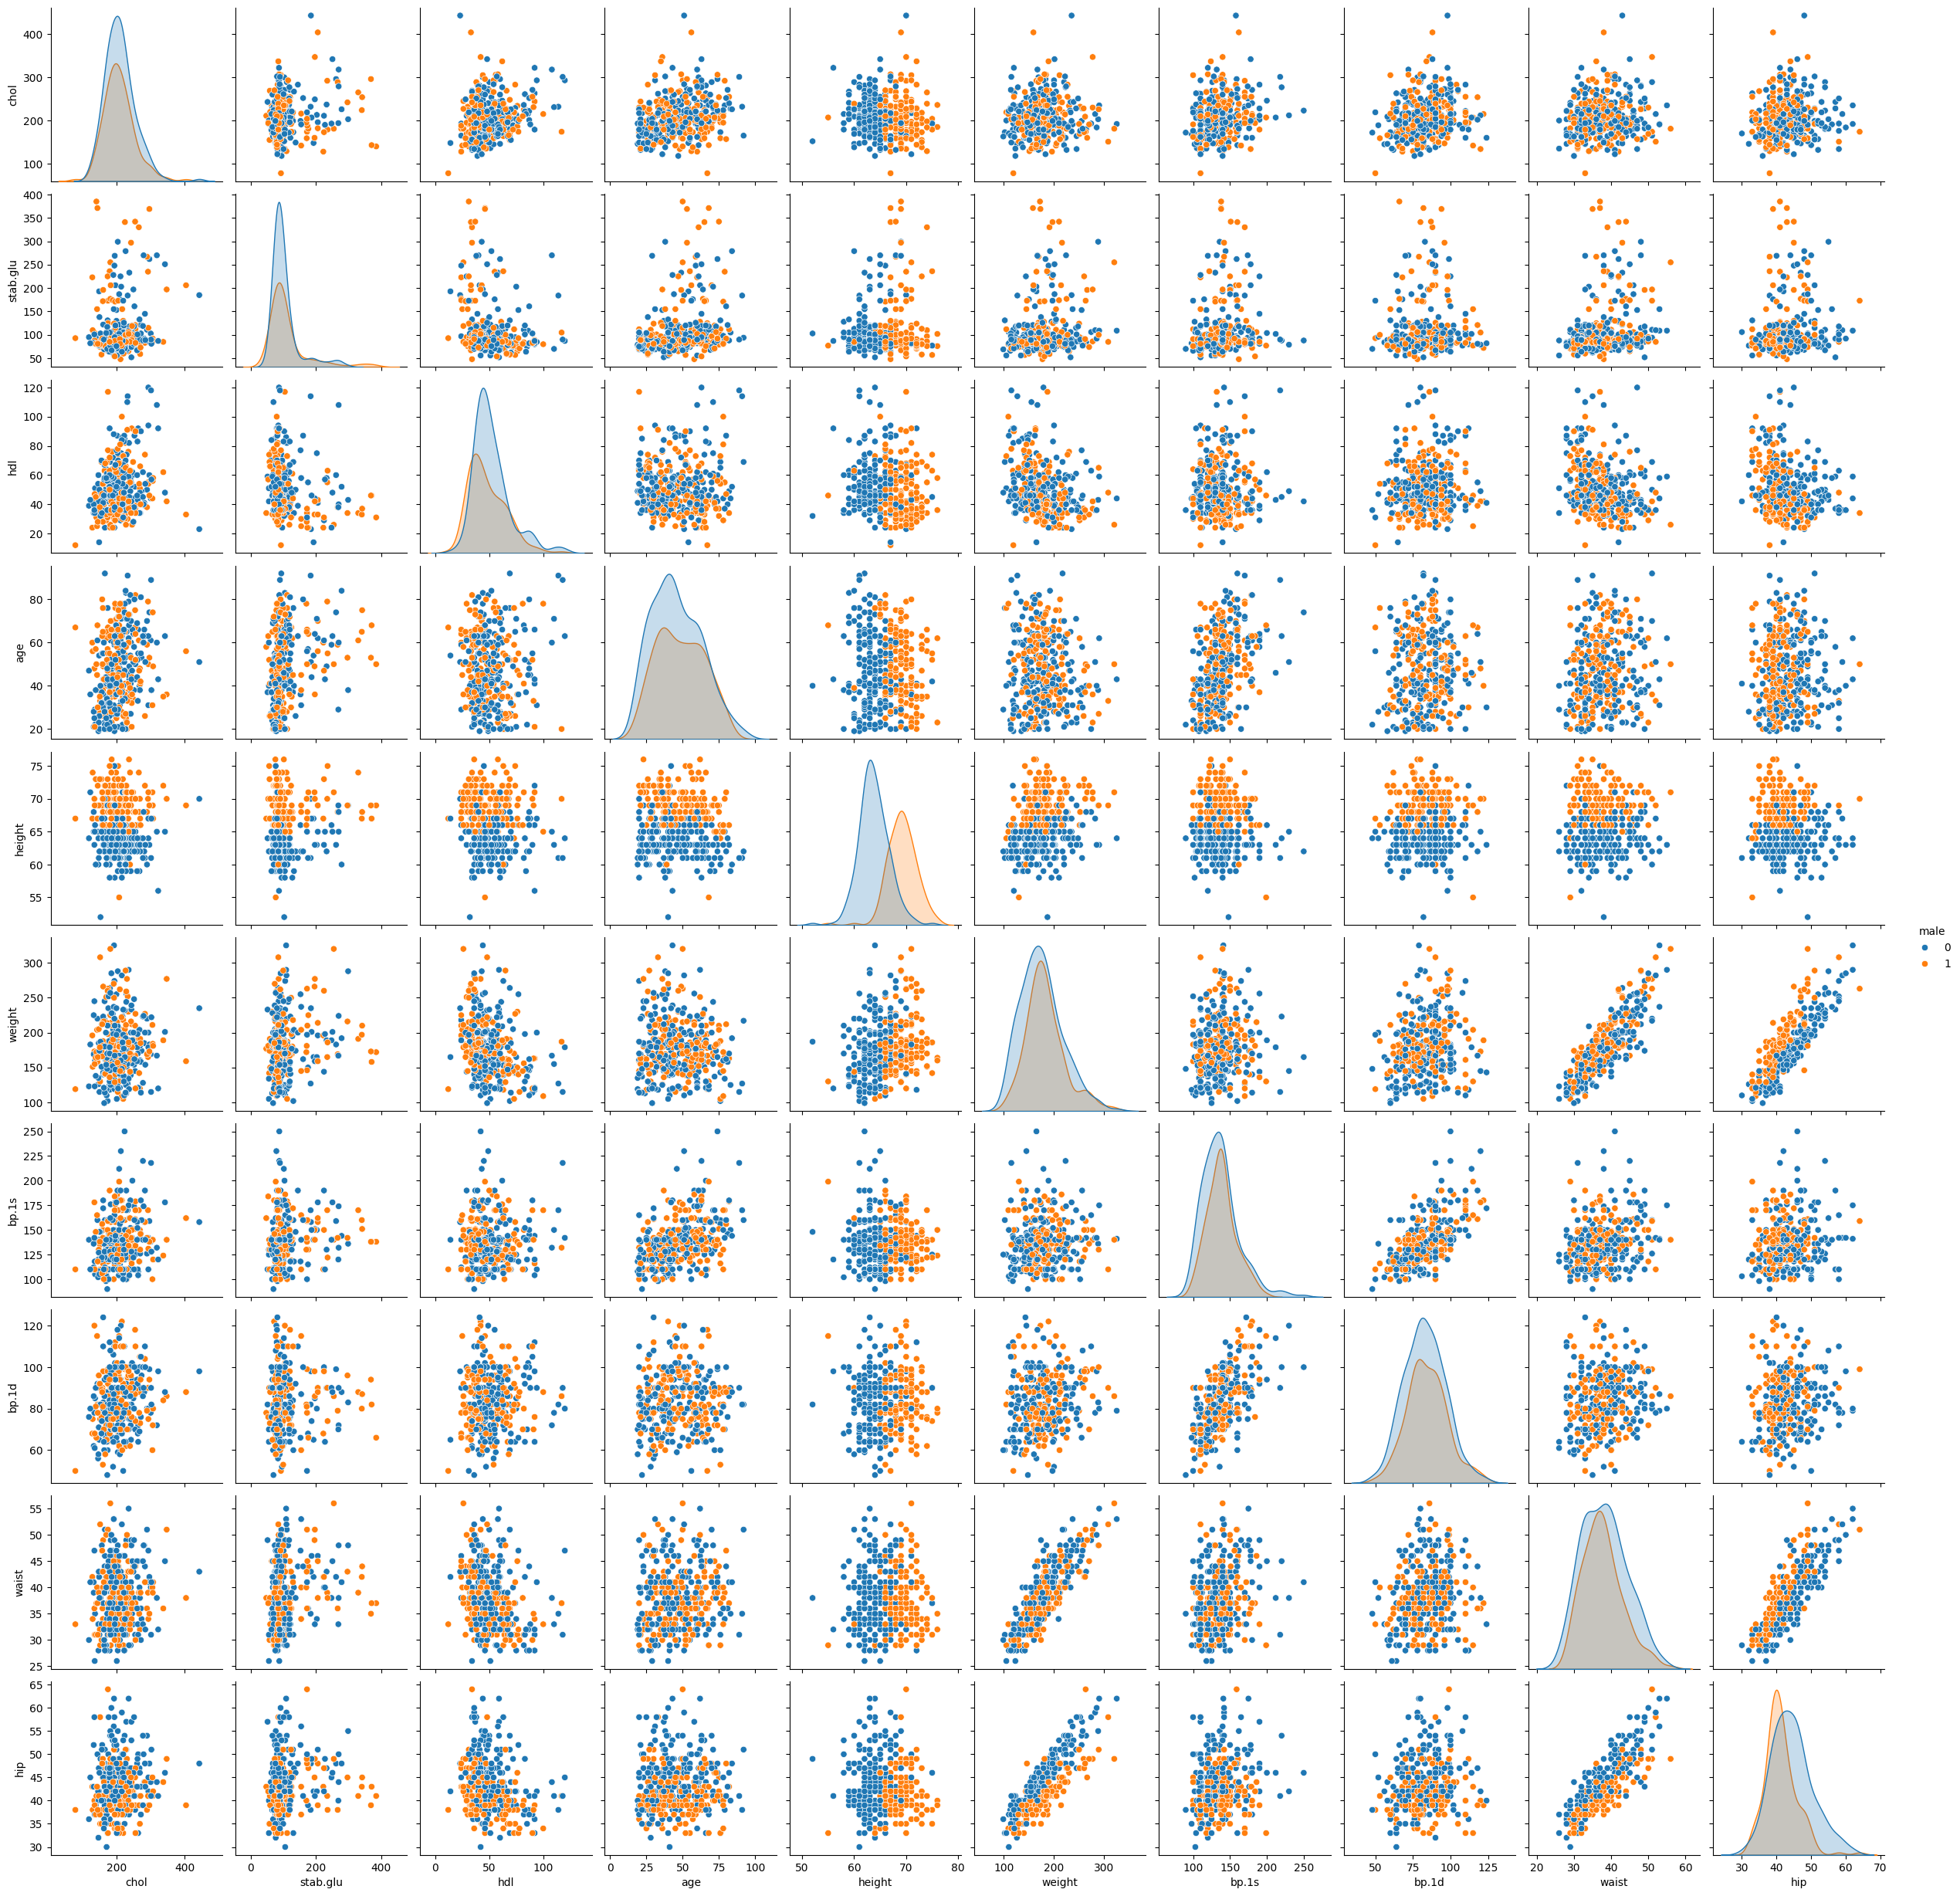

In [ ]:
## relationships between diffrent variables.....
sns.pairplot(eda_data,hue='male',diag_kind='kde')

In [ ]:
## on analysing the pair plot ,
## we can say that features are not linearly related ,
## instead their dependence on each other is just randomized
## they are note such depnedted by any fixed distribution

In [ ]:
##lets do a corelation plot to see how are variables are corelated

In [ ]:
corr_data=eda_data.corr()

<Axes: >

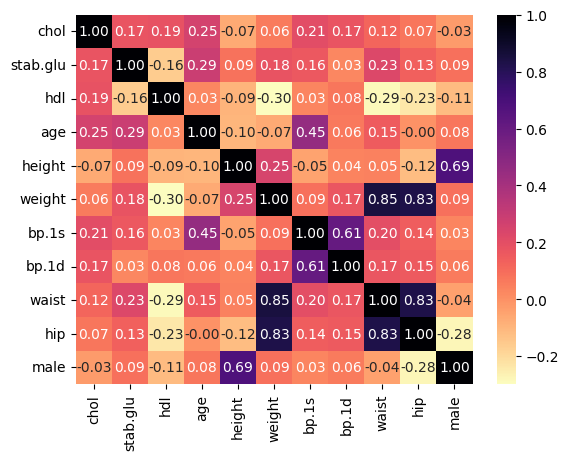

In [ ]:
sns.heatmap(corr_data,annot=True,fmt=".2f",cmap='magma_r')

In [ ]:
# we can see data for waist and hips are corealted with weight,
# and if we have weight and height already, it will not create much diffrence
# so we can remove the wiast and height features from our data
# others have a modelrate levbel of corelation so we can keep them

In [ ]:
modified_data=new_data.drop(columns=['waist','hip'])

In [ ]:
modified_data

,chol,stab.glu,hdl,age,height,weight,bp.1s,bp.1d,male,diabetes_or_not
0,203.0,82,56.0,46,62.0,121.0,118.0,59.0,0,0
1,165.0,97,24.0,29,64.0,218.0,112.0,68.0,0,0
2,228.0,92,37.0,58,61.0,256.0,190.0,92.0,0,0
3,78.0,93,12.0,67,67.0,119.0,110.0,50.0,1,0
4,249.0,90,28.0,64,68.0,183.0,138.0,80.0,1,1
...,...,...,...,...,...,...,...,...,...,...
397,301.0,90,118.0,89,61.0,115.0,218.0,90.0,0,0
398,296.0,369,46.0,53,69.0,173.0,138.0,94.0,1,1
399,284.0,89,54.0,51,63.0,154.0,140.0,100.0,0,0
400,194.0,269,38.0,29,69.0,167.0,120.0,70.0,0,1


In [ ]:
print(modified_data.describe())

             chol    stab.glu         hdl         age      height      weight  \
count  377.000000  377.000000  377.000000  377.000000  377.000000  377.000000   
mean   207.740053  107.519894   50.405836   46.920424   66.010610  177.997347   
std     44.641793   53.961080   17.414755   16.637532    3.910555   40.499836   
min     78.000000   48.000000   12.000000   19.000000   52.000000   99.000000   
25%    179.000000   81.000000   38.000000   34.000000   63.000000  151.000000   
50%    204.000000   90.000000   46.000000   45.000000   66.000000  174.000000   
75%    230.000000  108.000000   59.000000   60.000000   69.000000  200.000000   
max    443.000000  385.000000  120.000000   92.000000   76.000000  325.000000   

            bp.1s       bp.1d        male  diabetes_or_not  
count  377.000000  377.000000  377.000000       377.000000  
mean   137.395225   83.429708    0.416446         0.167109  
std     23.131798   13.527984    0.493624         0.373569  
min     90.000000   48.000

In [ ]:
## we need to do train test split again

In [ ]:
X=modified_data.iloc[:,:-1]
y=modified_data.iloc[:,-1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [ ]:
scaler=MinMaxScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# 3. Model Implementation

- #### For implementing this classification problem
- #### I will implement Decisison Tree Classifier here , as the data is not linear
- #### And does not follows a linear or any other pattern

- lets try with max depth = 7 first , then we will do hyperparamter tuning

In [ ]:
dtc=DecisionTreeClassifier(max_depth=7)

In [ ]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=7)

In [ ]:
y_pred=dtc.predict(X_test)
y_train_pred=dtc.predict(X_train)

In [ ]:
test_acc=accuracy_score(y_pred,y_test)
train_acc=accuracy_score(y_train_pred,y_train)


In [ ]:
train_acc,test_acc

(1.0, 0.88)

In [ ]:
cv_score=cross_val_score(dtc,X_train,y_train,cv=5,scoring='accuracy')

In [ ]:
print(cv_score)

[0.78431373 0.90196078 0.88       0.88       0.88      ]


In [ ]:
## In a particular fold value is bit higher then others,
## means data distribution is bad
## we will shuffle our data now

In [ ]:
scaler=MinMaxScaler()

In [ ]:
modified_data=modified_data.sample(frac=1,random_state=42).reset_index(drop=True)

X=modified_data.iloc[:,:-1]
y=modified_data.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
dtc2=DecisionTreeClassifier(max_depth=5)
dtc2.fit(X_train,y_train)

y_pred=dtc2.predict(X_test)
y_train_pred=dtc2.predict(X_train)

test_acc=accuracy_score(y_pred,y_test)
train_acc=accuracy_score(y_train_pred,y_train)

In [ ]:
modified_data

,chol,stab.glu,hdl,age,height,weight,bp.1s,bp.1d,male,diabetes_or_not
0,347.0,197,42.0,36,70.0,277.0,140.0,86.0,1,0
1,198.0,86,66.0,61,74.0,152.0,138.0,76.0,1,0
2,249.0,90,28.0,64,68.0,183.0,138.0,80.0,1,1
3,162.0,90,46.0,60,63.0,121.0,110.0,64.0,0,0
4,219.0,78,67.0,53,64.0,179.0,135.0,100.0,0,0
...,...,...,...,...,...,...,...,...,...,...
372,277.0,119,62.0,60,61.0,128.0,140.0,86.0,0,0
373,232.0,87,30.0,37,68.0,252.0,140.0,95.0,1,0
374,227.0,105,44.0,83,59.0,125.0,150.0,90.0,0,0
375,235.0,102,42.0,60,69.0,186.0,148.0,98.0,1,0


In [ ]:
cv_score=cross_val_score(dtc2,X_train,y_train,cv=5,scoring='accuracy')

In [ ]:
print(cv_score)

[0.92156863 0.90196078 0.92       0.84       0.86      ]


- This time as the data became randomised and not uneven distributed, we go similar amount of cv_scores in each fold

In [ ]:
print(f"Mean-cv-score = {cv_score.mean():.3f} +- std of {cv_score.std():.3f}")

Mean-cv-score = 0.889 +- std of 0.033


In [ ]:
## Ok so we saw that our acc on 4 th fold was bit higher than the other fold
## this might indicate little bit imbalvce in our data
## but lets move on to do hyper paramter tuning for max depth, and min sample split

In [ ]:
params={'max_depth':[x for x in range(2,10)] }

In [ ]:
## since pramters are less, like 1 in this case , grid search will work fine here

In [ ]:
model=DecisionTreeClassifier()

In [ ]:
gs=GridSearchCV(estimator=model,param_grid=params,cv=5,return_train_score=True,scoring='accuracy')

In [ ]:
gs.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9]},
             return_train_score=True, scoring='accuracy')

In [ ]:
y_pred=gs.best_estimator_.predict(X_test)
y_train_pred=gs.best_estimator_.predict(X_train)

In [ ]:
## Previous Scores

prev_y_pred=dtc2.predict(X_test)
prev_y_train_pred=dtc2.predict(X_train)

prev_test_acc=accuracy_score(prev_y_pred,y_test)
prev_train_acc=accuracy_score(prev_y_train_pred,y_train)

In [ ]:
test_acc=accuracy_score(y_pred,y_test)
train_acc=accuracy_score(y_train_pred,y_train)

In [ ]:
print(f"---Train Scores Comparision---\n\nTrain Accuracy After GridSearch: {train_acc:.3f}\nTrain Accuracy Without GridSearch: {prev_train_acc:.3f}\n")
print(f"---Test Scores Comparision---\n\nTest Accuracy After GridSearch: {test_acc:.3f}\nTest Accuracy Without GridSearch: {prev_test_acc:.3f}")

---Train Scores Comparision---

Train Accuracy After GridSearch: 0.952
Train Accuracy Without GridSearch: 0.984

---Test Scores Comparision---

Test Accuracy After GridSearch: 0.912
Test Accuracy Without GridSearch: 0.872


- This time test accuracy was improved
- and there is a slight variation in train accuracy

# 4. Model Evaluation

Lets Plot scores in train vs test

In [ ]:
data_grid_results=pd.DataFrame(gs.cv_results_)

In [ ]:
data_grid_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.001364,0.002728,0.000000,0.000000,2,{'max_depth': 2},0.901961,0.941176,0.90,0.84,...,0.896627,0.032380,2,0.925373,0.920398,0.940594,0.945545,0.930693,0.932521,0.009340
1,0.001543,0.002578,0.002784,0.002888,3,{'max_depth': 3},0.901961,0.941176,0.92,0.84,...,0.900627,0.033756,1,0.935323,0.945274,0.945545,0.965347,0.960396,0.950377,0.010959
2,0.001659,0.003319,0.002060,0.003203,4,{'max_depth': 4},0.921569,0.901961,0.92,0.84,...,0.888706,0.032958,3,0.960199,0.975124,0.965347,0.970297,0.970297,0.968253,0.005077
3,0.003261,0.003583,0.001581,0.003162,5,{'max_depth': 5},0.901961,0.901961,0.88,0.86,...,0.884784,0.015812,4,0.980100,0.990050,0.975248,0.975248,0.985149,0.981159,0.005762
4,0.002032,0.003523,0.001601,0.001894,6,{'max_depth': 6},0.901961,0.901961,0.88,0.80,...,0.868784,0.037777,7,0.990050,0.995025,0.985149,0.995050,0.995050,0.992064,0.003962
5,0.002291,0.002449,0.000651,0.001303,7,{'max_depth': 7},0.901961,0.901961,0.90,0.80,...,0.872784,0.039760,5,1.000000,1.000000,0.990099,0.995050,0.995050,0.996040,0.003705
6,0.002644,0.003263,0.002310,0.002263,8,{'max_depth': 8},0.882353,0.901961,0.88,0.82,...,0.864863,0.030140,8,1.000000,1.000000,0.995050,1.000000,1.000000,0.999010,0.001980
7,0.003951,0.002652,0.000000,0.000000,9,{'max_depth': 9},0.901961,0.921569,0.88,0.82,...,0.872706,0.037800,6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


Lets plot with the max_depth paramter and see what we got

In [ ]:
mean_test_scores=data_grid_results['mean_test_score']
mean_train_scores=data_grid_results['mean_train_score']
max_depth_paramter=data_grid_results['param_max_depth']

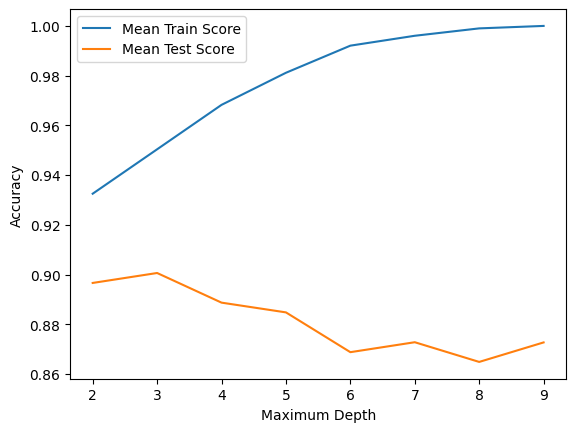

In [ ]:
plt.plot(max_depth_paramter, mean_train_scores, label='Mean Train Score')
plt.plot(max_depth_paramter, mean_test_scores, label='Mean Test Score')
plt.xlabel('Maximum Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Upon looking into the graph we can say as below
- after depth of 7 , train accuracy approaches to 1 which leads to fitting of data closely
- we got best test accuracy at depth 3 and train acuuracy is alsoat good amount at this depth
- although test score is quite variable amoung the model, but at max depth 3 we get best accuracy

##### Lets plot Bias and Variance

In [ ]:
bias_overall=[]
var_overall=[]
loss_train_overall=[]
loss_test_overall=[]

for i in range(2, 20):
    dtc = DecisionTreeClassifier(max_depth=i)

    X_train_array = np.array(X_train)
    y_train_array = np.array(y_train)
    X_test_array = np.array(X_test)
    y_test_array = np.array(y_test)

    avg_exp_loss, avg_bias, avg_var = bias_variance_decomp(
        dtc,
        X_train_array, y_train_array,
        X_test_array, y_test_array,
        loss='0-1_loss',
        random_seed=42
    )

    bias_overall.append(avg_bias)
    var_overall.append(avg_var)
    loss_test_overall.append(avg_exp_loss)

    avg_exp_loss, avg_bias, avg_var = bias_variance_decomp(
        dtc,
        X_train_array, y_train_array,
        X_train_array, y_train_array,
        loss='0-1_loss',
        random_seed=42
    )

    loss_train_overall.append(avg_exp_loss)


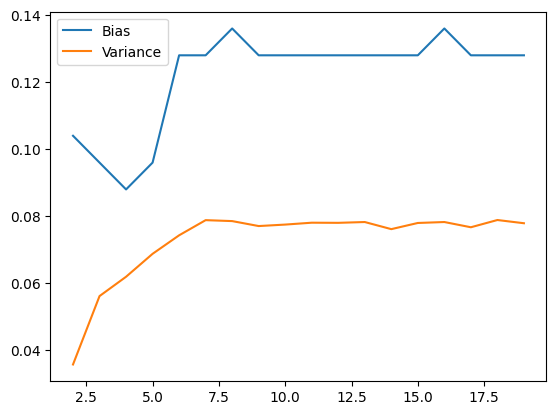

In [ ]:
plt.plot(range(2,20),bias_overall)
plt.plot(range(2,20),var_overall)
plt.legend(['Bias','Variance'])

#### At about max depth 4 ,bias is minimum and variance is at a good value
- after that bias increase then remains similar to a particular value
becomes constant
- var increase after depth 4 in a exponential manner

### Lets calulate RMSE

In [ ]:
test_RMSE=np.sqrt(mean_squared_error(y_pred,y_test))
train_RMSE=np.sqrt(mean_squared_error(y_train_pred,y_train))

In [ ]:
print(f"Train RMSE :{train_RMSE:.3f}\nTest RMSE :{test_RMSE:.3f}")

Train RMSE :0.218
Test RMSE :0.297


#### RMSE for test and train appears to be good.

### Overall Model Performance
Our model now after hyperprameter tunuing and many ammeds and preprocessing finally performs well on new train data that we created to test our model and its give a good acuuracy and RMSE values.
- RMSE score for Train is :0.218
- RMSE score for Test is :0.287
<br>Quite good <br><br>

#### Train Scores Comparision

<hr>

###### Before hyperparameter tuning
- Train Accuracy Without GridSearch: 0.984

###### After hyperparameter tuning
- Train Accuracy After GridSearch: 0.952

<br>
<h4>Test Scores Comparision</h4>
<hr>

###### Before hyperparameter tuning
- Test Accuracy Without GridSearch: 0.872

###### After hyperparameter tuning
- Test Accuracy After GridSearch: 0.912

<br>